# **CÀI ĐẶT THƯ VIỆN**

In [1]:
!pip install yfinance pyswarms tensorflow scikit-learn openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pyswarms as ps
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings('ignore')
print("Thư viện đã được nhập thành công.")

Thư viện đã được nhập thành công.


# **GET THE DATASET**

Tải dữ liệu lịch sử dài (benchmark) từ năm 2015-01-01 đến nay (hơn 11 năm, ~2800+ mẫu) — đủ dài để huấn luyện và đánh giá khoa học.

In [3]:
import pandas as pd
import yfinance as yf
from datetime import datetime
import os

def lay_du_lieu_nang_cao(start_date="2010-01-01"):
    tickers = {
        'Gold': 'GC=F',
        'DXY': 'DX-Y.NYB',
        'Oil': 'CL=F',
        'S&P500': '^GSPC',
        'Bond_10Y': '^TNX'
    }

    print("Đang tải dữ liệu đa biến...")
    all_data = yf.download(list(tickers.values()), start=start_date, auto_adjust=True)
    df = pd.DataFrame()
    df['Date'] = all_data.index
    df['Gold_Close'] = all_data['Close'][tickers['Gold']].values
    df['DXY'] = all_data['Close'][tickers['DXY']].values
    df['Oil'] = all_data['Close'][tickers['Oil']].values
    df['SP500'] = all_data['Close'][tickers['S&P500']].values
    df['Bond_Yield'] = all_data['Close'][tickers['Bond_10Y']].values
    df['Gold_Volume'] = all_data['Volume'][tickers['Gold']].values
    df = df.ffill().dropna()
    print(f"Đã tải xong {len(df)} dòng dữ liệu đa biến.")
    return df

In [4]:
# Tải dữ liệu đa biến và khởi tạo biến toàn cục
df_benchmark = lay_du_lieu_nang_cao("2015-01-01")
print(f"Đã khởi tạo df_benchmark thành công.")

Đang tải dữ liệu đa biến...


[*********************100%***********************]  5 of 5 completed

Đã tải xong 2838 dòng dữ liệu đa biến.
Đã khởi tạo df_benchmark thành công.


In [5]:
print(df_benchmark)

           Date   Gold_Close        DXY         Oil        SP500  Bond_Yield  \
0    2015-01-02  1186.000000  91.080002   52.689999  2058.199951       2.123   
1    2015-01-05  1203.900024  91.379997   50.040001  2020.579956       2.039   
2    2015-01-06  1219.300049  91.500000   47.930000  2002.609985       1.963   
3    2015-01-07  1210.599976  91.889999   48.650002  2025.900024       1.954   
4    2015-01-08  1208.400024  92.370003   48.790001  2062.139893       2.016   
...         ...          ...        ...         ...          ...         ...   
2833 2026-04-06  4656.799805  99.980003  112.410004  6611.830078       4.335   
2834 2026-04-07  4657.100098  99.639999  112.949997  6616.850098       4.343   
2835 2026-04-08  4749.500000  99.129997   94.410004  6782.810059       4.291   
2836 2026-04-09  4792.200195  98.820000   97.870003  6824.660156       4.293   
2837 2026-04-10  4771.000000  98.697998   95.629997  6816.890137       4.317   

      Gold_Volume  
0           138.0  

# Chuẩn bị dữ liệu & Hàm tạo dataset

In [6]:
def create_multivariate_dataset(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# Chuẩn bị dữ liệu từ df_benchmark
df = df_benchmark.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

scaler_gold = MinMaxScaler(feature_range=(0, 1))
scaler_gold.fit(df[['Gold_Close']])

features_to_scale = df.drop(columns=['Date']).columns
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features_to_scale])

num_features = scaled_data.shape[1]
print(f"Dữ liệu đã sẵn sàng để nghiên cứu chuyên sâu. Số tính năng: {num_features}")

Dữ liệu đã sẵn sàng để nghiên cứu chuyên sâu. Số tính năng: 6


In [7]:
print(f"Tổng số ngày dữ liệu: {len(df)}")

Tổng số ngày dữ liệu: 2838


# **CORRELATION MATRIX HEATMAP**

## Biểu diễn ma trận tương quan

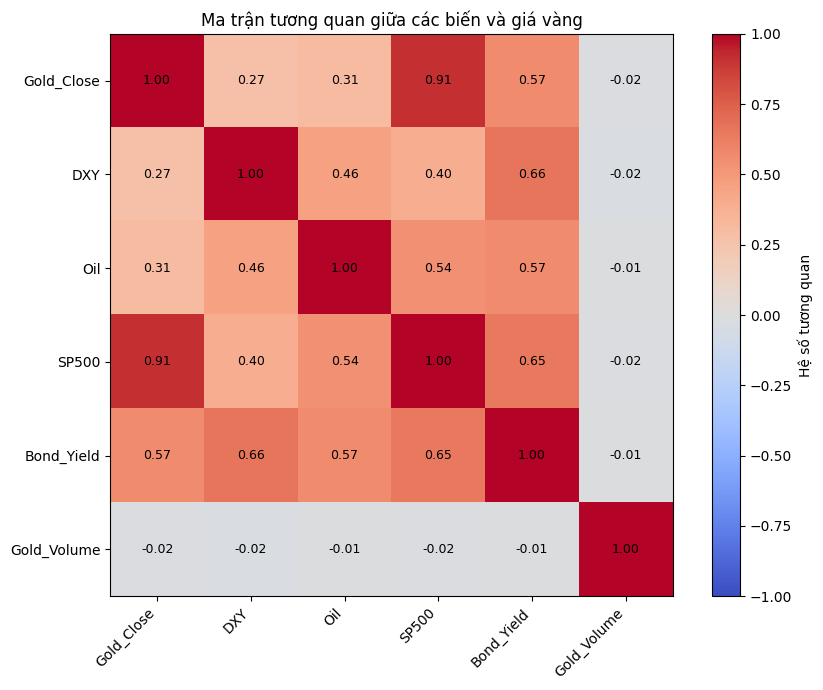

Tương quan với Gold_Close (sắp xếp theo |corr| giảm dần):
SP500          0.906594
Bond_Yield     0.567624
Oil            0.312141
DXY            0.274857
Gold_Volume   -0.019198
Name: Gold_Close, dtype: float64

Biến ảnh hưởng mạnh nhất đến Gold_Close theo tương quan tuyến tính: SP500 (corr = 0.907)


In [ ]:
# Tính ma trận tương quan giữa các biến số
corr_df = df_benchmark.drop(columns=['Date']).corr(numeric_only=True)

# Vẽ heatmap tương quan
fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_df.columns)))
ax.set_yticks(np.arange(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_df.columns)

# Ghi giá trị tương quan lên từng ô để dễ đọc
for i in range(corr_df.shape[0]):
    for j in range(corr_df.shape[1]):
        ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=9)

cbar = fig.colorbar(heatmap, ax=ax)
cbar.set_label('Hệ số tương quan')

plt.title('Ma trận tương quan giữa các biến và giá vàng')
plt.tight_layout()
plt.show()

# Xếp hạng mức ảnh hưởng đến Gold_Close theo độ lớn |corr|
gold_corr_rank = corr_df['Gold_Close'].drop('Gold_Close').sort_values(key=lambda x: x.abs(), ascending=False)
print('Tương quan với Gold_Close (sắp xếp theo |corr| giảm dần):')
print(gold_corr_rank)

most_related_feature = gold_corr_rank.index[0]
most_related_value = gold_corr_rank.iloc[0]
print(f"\nBiến ảnh hưởng mạnh nhất đến Gold_Close theo tương quan tuyến tính: {most_related_feature} (corr = {most_related_value:.3f})")

# **PSO-LSTM**

## Hàm mục tiêu cho PSO

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

def calculate_directional_accuracy(y_true, y_pred):
    """Tính tỉ lệ dự báo đúng hướng tăng/giảm của giá"""
    y_true_diff = np.diff(y_true) > 0
    y_pred_diff = np.diff(y_pred) > 0
    return np.mean(y_true_diff == y_pred_diff) * 100


# ====================== CẤU HÌNH PSO CẢI THIỆN CHẤT LƯỢNG ======================
train_eval_ratio = 0.85      # Tăng để fitness chính xác hơn

full_train_size = int(len(scaled_data) * 0.80)

X_all_temp, y_all_temp = create_multivariate_dataset(scaled_data, look_back=60)

train_eval_size = int(full_train_size * train_eval_ratio)

X_train_eval = X_all_temp[:train_eval_size]
y_train_eval = y_all_temp[:train_eval_size]

X_val_full = X_all_temp[full_train_size:]
y_val_full = y_all_temp[full_train_size:]

print(f"PSO sử dụng {train_eval_ratio*100:.0f}% dữ liệu train để đánh giá")


# ====================== HÀM OBJECTIVE TỐI ƯU HƠN ======================
def objective_function_advanced(x):
    fitness = []
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    for particle in x:
        look_back     = max(30, min(120, int(particle[0])))
        hidden_units  = max(80, min(280, int(particle[1])))
        learning_rate = max(0.0005, min(0.008, particle[2]))
        batch_size    = max(16, min(256, int(particle[3])))   # giảm max batch để ổn định
        num_layers    = max(1, min(3, int(particle[4])))
        dropout_rate  = max(0.05, min(0.45, particle[5]))     # dropout min 0.05

        try:
            X_all, y_all = create_multivariate_dataset(scaled_data, look_back)

            X_train_sub = X_all[:train_eval_size]
            y_train_sub = y_all[:train_eval_size]
            X_val_sub   = X_all[full_train_size:]
            y_val_sub   = y_all[full_train_size:]

            model = Sequential()
            for i in range(num_layers):
                return_seq = (i < num_layers - 1)
                if i == 0:
                    model.add(LSTM(hidden_units, return_sequences=return_seq,
                                  input_shape=(look_back, num_features)))
                else:
                    model.add(LSTM(hidden_units, return_sequences=return_seq))
                model.add(Dropout(dropout_rate))

            model.add(Dense(1))
            model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

            model.fit(X_train_sub, y_train_sub, 
                      epochs=6,                    
                      batch_size=batch_size,
                      validation_data=(X_val_sub, y_val_sub),
                      callbacks=[early_stop], 
                      verbose=0)

            pred_scaled = model.predict(X_val_sub, verbose=0)
            y_true = scaler_gold.inverse_transform(y_val_sub.reshape(-1, 1)).flatten()
            pred   = scaler_gold.inverse_transform(pred_scaled).flatten()

            rmse = np.sqrt(mean_squared_error(y_true, pred))
            mape = mean_absolute_percentage_error(y_true, pred)

            fitness.append(rmse * (1 + 0.6 * mape))   # Tăng penalty MAPE nhẹ

        except:
            fitness.append(1e6)
    
    return np.array(fitness)


print("Hàm objective đã được tối ưu để hạ best_cost.")

PSO sử dụng 85% dữ liệu train để đánh giá
Hàm objective đã được tối ưu để hạ best_cost.


PSO sử dụng 85% dữ liệu train để đánh giá
Hàm objective đã được tối ưu để hạ best_cost.


## Chạy PSO tối ưu siêu tham số

In [ ]:
bounds = ([30, 80, 0.0005, 16, 1, 0.05],
          [120, 280, 0.008, 256, 3, 0.45])

options = {'c1': 2.0, 'c2': 2.0, 'w': 0.78}

optimizer = ps.single.GlobalBestPSO(
    n_particles=12,
    dimensions=6,
    options=options,
    bounds=bounds
)

print("Đang chạy PSO cải thiện lần cuối...")
cost, pos = optimizer.optimize(objective_function_advanced, iters=10)

print(f"\nPSO HOÀN THÀNH! Best cost = {cost:.4f}")
print(f"Look-back     : {int(pos[0])}")
print(f"Hidden units  : {int(pos[1])}")
print(f"Learning rate : {pos[2]:.5f}")
print(f"Batch size    : {int(pos[3])}")
print(f"LSTM layers   : {int(pos[4])}")
print(f"Dropout rate  : {pos[5]:.2f}")

2026-04-11 14:38:44,130 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.78}


Đang chạy PSO cải thiện lần cuối...


pyswarms.single.global_best:  90%|█████████ |9/10, best_cost=628    

## Huấn luyện mô hình cuối cùng & Đánh giá

In [16]:
# ====================== HUẤN LUYỆN FINAL MODEL (theo best PSO) ======================
best_look_back = int(pos[0])
best_units     = int(pos[1])
best_lr        = float(pos[2])
best_batch     = int(pos[3])
best_layers    = int(pos[4])
best_dropout   = float(pos[5])

# Tạo dataset cuối cùng
X_all, y_all = create_multivariate_dataset(scaled_data, best_look_back)
train_size = int(len(X_all) * 0.8)

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test,  y_test  = X_all[train_size:], y_all[train_size:]

# Xây dựng mô hình cuối cùng
final_model = Sequential()
for i in range(best_layers):
    return_seq = (i < best_layers - 1)
    if i == 0:
        final_model.add(LSTM(best_units, return_sequences=return_seq,
                            input_shape=(best_look_back, num_features)))
    else:
        final_model.add(LSTM(best_units, return_sequences=return_seq))
    final_model.add(Dropout(best_dropout))

final_model.add(Dense(1))
final_model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')

# EarlyStopping theo các paper
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

print("Huấn luyện Final PSO-LSTM model với best parameters...")
history = final_model.fit(X_train, y_train,
                          epochs=100,
                          batch_size=best_batch,
                          validation_split=0.15,
                          callbacks=[early_stop],
                          verbose=1)

Huấn luyện Final PSO-LSTM model với best parameters...
Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - loss: 0.0254 - val_loss: 0.0061
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - loss: 2.3537e-04 - val_loss: 0.0027
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - loss: 1.9824e-04 - val_loss: 0.0022
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - loss: 1.5916e-04 - val_loss: 5.8520e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - loss: 1.2226e-04 - val_loss: 8.0720e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step - loss: 1.1328e-04 - val_loss: 8.7401e-04
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 225ms/step - loss: 1.0841e-04 - val_loss: 3.0496e-04
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - loss: 9.6611e-05 - val_loss: 7.6434e-04
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - loss: 8.5719e-05 - val_loss: 2.4213e-04
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 248ms/step - loss: 9.4684e-05 - val_loss: 4.2510e-04


Đánh giá và dự đoán

In [19]:
# Dự đoán
pred_scaled = final_model.predict(X_test, verbose=0)
pred = scaler_gold.inverse_transform(pred_scaled)
y_true = scaler_gold.inverse_transform(y_test.reshape(-1, 1))

# Metrics PSO-LSTM
mae   = mean_absolute_error(y_true, pred)
rmse  = np.sqrt(mean_squared_error(y_true, pred))
mape  = mean_absolute_percentage_error(y_true, pred) * 100
r2    = r2_score(y_true, pred)
dir_acc = calculate_directional_accuracy(y_true.flatten(), pred.flatten())

print("\n" + "="*80)
print("KẾT QUẢ PSO-LSTM MULTIVARIATE (TỐI ƯU THEO CÁC NGHIÊN CỨU)")
print("="*80)
print(f"MAE                  : {mae:.2f} USD")
print(f"RMSE                 : {rmse:.2f} USD")
print(f"MAPE                 : {mape:.2f}%")
print(f"R²                   : {r2:.4f}")
print(f"Directional Accuracy : {dir_acc:.2f}%")
print("="*80)


KẾT QUẢ PSO-LSTM MULTIVARIATE (TỐI ƯU THEO CÁC NGHIÊN CỨU)
MAE                  : 141.69 USD
RMSE                 : 193.97 USD
MAPE                 : 3.83%
R²                   : 0.9496
Directional Accuracy : 51.91%


## Vẽ biểu đồ dự đoán

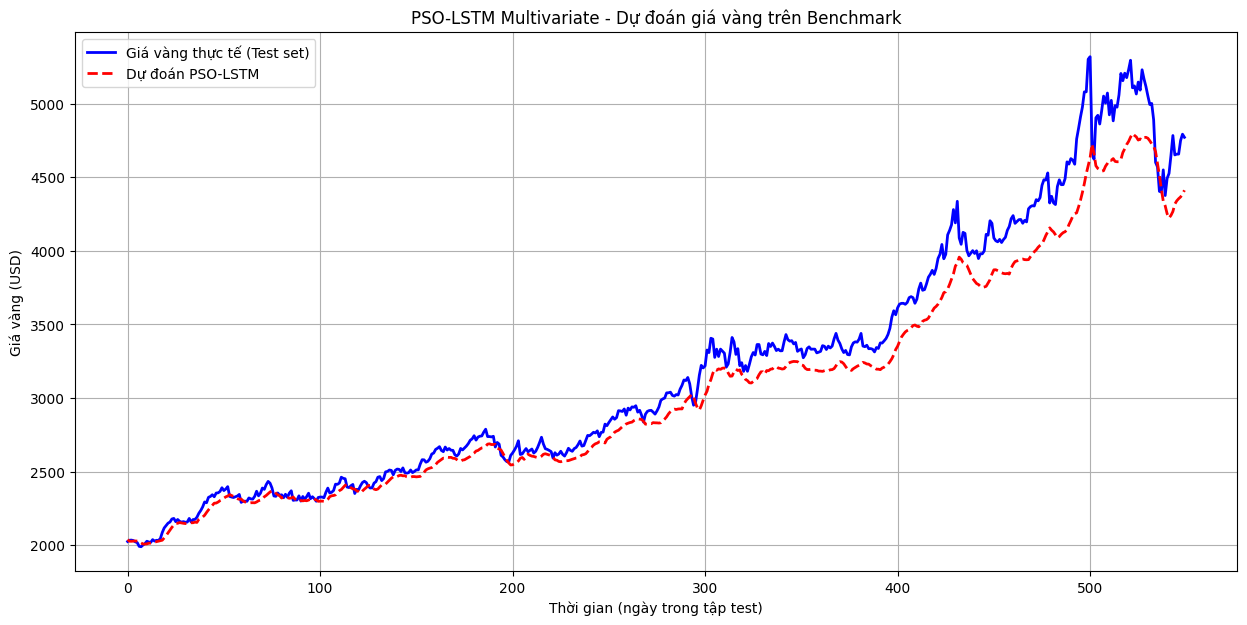

In [20]:
plt.figure(figsize=(15, 7))
plt.plot(y_true, label='Giá vàng thực tế (Test set)', color='blue', linewidth=2)
plt.plot(pred, label='Dự đoán PSO-LSTM', color='red', linestyle='--', linewidth=2)
plt.title('PSO-LSTM Multivariate - Dự đoán giá vàng trên Benchmark')
plt.xlabel('Thời gian (ngày trong tập test)')
plt.ylabel('Giá vàng (USD)')
plt.legend()
plt.grid(True)
plt.show()

Tải model

In [21]:
import joblib
import json
from datetime import datetime

# Lưu mô hình Keras
final_model.save('model_PSO_LSTM_final.h5')
print("Đã lưu model: model_PSO_LSTM_final.h5")

# Lưu Scaler
joblib.dump(scaler_gold, 'scaler_gold.pkl')
print("Đã lưu scaler: scaler_gold.pkl")

# Lưu Best Parameters từ PSO
best_params = {
    "look_back": int(pos[0]),
    "hidden_units": int(pos[1]),
    "learning_rate": float(pos[2]),
    "batch_size": int(pos[3]),
    "num_layers": int(pos[4]),
    "dropout_rate": float(pos[5]),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print("Đã lưu best parameters: best_params.json")

# Lưu Metrics đánh giá
metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "MAPE": float(mape),
    "R2": float(r2),
    "Directional_Accuracy": float(dir_acc),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Đã lưu metrics: model_metrics.json")

print("\nLƯU TRỮ HOÀN TẤT!")
print("Các file đã được lưu:")
print("   • model_PSO_LSTM_final.h5")
print("   • scaler_gold.pkl")
print("   • best_params.json")
print("   • model_metrics.json")

2026-04-11 08:58:30,651 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Đã lưu model: model_PSO_LSTM_final.h5
Đã lưu scaler: scaler_gold.pkl
Đã lưu best parameters: best_params.json
Đã lưu metrics: model_metrics.json

LƯU TRỮ HOÀN TẤT!
Các file đã được lưu:
   • model_PSO_LSTM_final.h5
   • scaler_gold.pkl
   • best_params.json
   • model_metrics.json


# **LSTM BASELINE**

## Xây dựng & Huấn luyện LSTM Baseline

In [ ]:
# Tham số cố định hợp lý cho Baseline
baseline_look_back = 60
baseline_units     = 128
baseline_layers    = 2
baseline_lr        = 0.001
baseline_dropout   = 0.2
baseline_batch     = 32
baseline_epochs    = 60

# Tạo dataset với look_back cố định
X_all_base, y_all_base = create_multivariate_dataset(scaled_data, baseline_look_back)
train_size = int(len(X_all_base) * 0.8)

X_train_base = X_all_base[:train_size]
y_train_base = y_all_base[:train_size]
X_test_base  = X_all_base[train_size:]
y_test_base  = y_all_base[train_size:]

# Xây dựng mô hình Baseline
baseline_model = Sequential()
for i in range(baseline_layers):
    return_seq = (i < baseline_layers - 1)
    if i == 0:
        baseline_model.add(LSTM(baseline_units, return_sequences=return_seq,
                               input_shape=(baseline_look_back, num_features)))
    else:
        baseline_model.add(LSTM(baseline_units, return_sequences=return_seq))
    baseline_model.add(Dropout(baseline_dropout))

baseline_model.add(Dense(1))
baseline_model.compile(optimizer=Adam(learning_rate=baseline_lr), loss='mse')

print("Đang huấn luyện LSTM Baseline...")
baseline_model.fit(X_train_base, y_train_base,
                   epochs=baseline_epochs,
                   batch_size=baseline_batch,
                   validation_split=0.1,
                   verbose=1)

Đang huấn luyện LSTM Baseline...
Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 4.0620e-04 - val_loss: 3.0237e-04
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 2.3782e-04 - val_loss: 1.1325e-04
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 1.7882e-04 - val_loss: 1.3130e-04
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 1.7733e-04 - val_loss: 2.1492e-04
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 1.5968e-04 - val_loss: 1.8707e-04
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 1.5032e-04 - val_loss: 1.9168e-04
Epoch 8/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 1.3628e-04 - val_loss: 1.7052e-04
Epoch 9/60
 2/63 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 1.6307e-04 

## Đánh giá & Bảng so sánh PSO-LSTM vs LSTM Baseline

In [17]:
# ====================== DỰ ĐOÁN VÀ ĐÁNH GIÁ BASELINE ======================
pred_base_scaled = baseline_model.predict(X_test_base, verbose=0)
pred_base = scaler_gold.inverse_transform(pred_base_scaled)
y_true_base = scaler_gold.inverse_transform(y_test_base.reshape(-1, 1))

# Tính metrics cho Baseline
mae_base   = mean_absolute_error(y_true_base, pred_base)
rmse_base  = np.sqrt(mean_squared_error(y_true_base, pred_base))
mape_base  = mean_absolute_percentage_error(y_true_base, pred_base) * 100
r2_base    = r2_score(y_true_base, pred_base)
dir_acc_base = calculate_directional_accuracy(y_true_base.flatten(), pred_base.flatten())

# ====================== BẢNG SO SÁNH ======================
comparison = pd.DataFrame({
    "Metric": ["MAE (USD)", "RMSE (USD)", "MAPE (%)", "R²", "Directional Accuracy (%)"],
    "PSO-LSTM": [f"{mae:.2f}", f"{rmse:.2f}", f"{mape:.2f}", f"{r2:.4f}", f"{dir_acc:.2f}"],
    "LSTM Baseline": [f"{mae_base:.2f}", f"{rmse_base:.2f}", f"{mape_base:.2f}",
                      f"{r2_base:.4f}", f"{dir_acc_base:.2f}"]
})

print("\n" + "="*80)
print("📊 BẢNG SO SÁNH PSO-LSTM vs LSTM BASELINE")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Lưu kết quả so sánh ra file Excel (dễ copy vào báo cáo)
comparison.to_excel("so_sanh_PSO_vs_Baseline.xlsx", index=False)
print("💾 Đã lưu bảng so sánh vào file: so_sanh_PSO_vs_Baseline.xlsx")


📊 BẢNG SO SÁNH PSO-LSTM vs LSTM BASELINE
                  Metric PSO-LSTM LSTM Baseline
               MAE (USD)   141.69         90.94
              RMSE (USD)   193.97        138.43
                MAPE (%)     3.83          2.41
                      R²   0.9496        0.9745
Directional Accuracy (%)    51.91         52.61


ModuleNotFoundError: No module named 'openpyxl'

# Vẽ biểu đồ so sánh hai mô hình

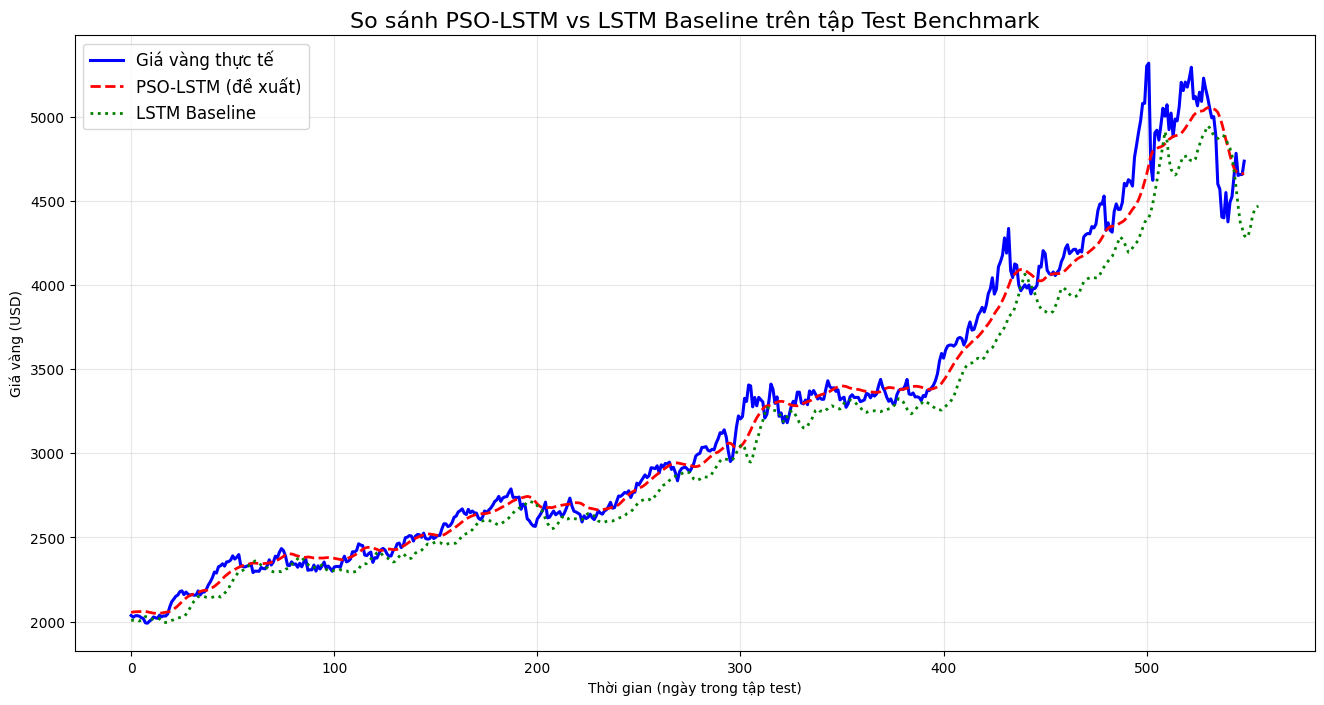

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(y_true, label='Giá vàng thực tế', color='blue', linewidth=2.2)
plt.plot(pred, label='PSO-LSTM (đề xuất)', color='red', linestyle='--', linewidth=2)
plt.plot(pred_base, label='LSTM Baseline', color='green', linestyle=':', linewidth=2)
plt.title('So sánh PSO-LSTM vs LSTM Baseline trên tập Test Benchmark', fontsize=16)
plt.xlabel('Thời gian (ngày trong tập test)')
plt.ylabel('Giá vàng (USD)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Script Dự đoán Tương lai (Multi-step Forecast)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def forecast_future(model, last_sequence, n_days, scaler, look_back, num_features):
    """
    Dự đoán n ngày tiếp theo bằng phương pháp đệ quy.
    """
    future_predictions = []
    
    # Bắt đầu với chuỗi dữ liệu cuối cùng trong tập dataset
    # Shape: (1, look_back, num_features)
    current_batch = last_sequence.reshape((1, look_back, num_features))
    
    for i in range(n_days):
        # Dự đoán giá trị tiếp theo (scaled)
        current_pred = model.predict(current_batch, verbose=0)
        
        # Lưu kết quả dự đoán
        future_predictions.append(current_pred[0, 0])
        
        # Cập nhật chuỗi dữ liệu cho lần dự đoán kế tiếp:
        # 1. Loại bỏ giá trị đầu tiên trong chuỗi
        # 2. Thêm giá trị vừa dự đoán vào cuối chuỗi
        # Lưu ý: Vì đây là đa biến, các biến phụ trợ (features khác) chúng ta sẽ 
        # giữ hằng số bằng giá trị cuối cùng hoặc cập nhật theo logic riêng. 
        # Ở đây ta giữ hằng số các feature phụ để đơn giản hóa.
        
        new_row = current_batch[0, -1, :].copy() 
        new_row[0] = current_pred[0, 0] # Giả sử cột 0 là giá vàng (cần dự đoán)
        
        # Chèn row mới vào cuối và đẩy row cũ ra
        current_batch = np.append(current_batch[:, 1:, :], [[new_row]], axis=1)

    # Chuyển đổi ngược về đơn vị giá USD
    # Cần tạo dummy array để scaler.inverse_transform hoạt động nếu scaler dùng cho nhiều cột
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    
    # Nếu scaler của bạn chỉ dành riêng cho Gold:
    final_forecast = scaler.inverse_transform(future_predictions)
    
    return final_forecast

# ==========================================================
# THỰC THI DỰ ĐOÁN
# ==========================================================
# 1. Lấy chuỗi dữ liệu cuối cùng từ tập scaled_data
n_future_days = 30 # Dự đoán 30 ngày tới
last_sequence = scaled_data[-best_look_back:]

# 2. Gọi hàm dự đoán
forecasted_prices = forecast_future(
    final_model, 
    last_sequence, 
    n_future_days, 
    scaler_gold, 
    best_look_back, 
    num_features
)

# 3. Tạo khung thời gian cho tương lai (giả sử dự đoán từ ngày tiếp theo)
last_date = pd.to_datetime(df.index[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

# 4. Hiển thị kết quả
forecast_df = pd.DataFrame(data=forecasted_prices, index=future_dates, columns=['Predicted_Gold_Price'])
print("\nDỰ BÁO GIÁ VÀNG TRONG 30 NGÀY TỚI:")
print(forecast_df.head(10))

# 5. Vẽ đồ thị
plt.figure(figsize=(12, 6))
plt.plot(forecast_df.index, forecast_df['Predicted_Gold_Price'], color='orange', marker='o', label='Dự báo tương lai')
plt.title(f'Dự báo giá vàng trong {n_future_days} ngày tới (PSO-LSTM)')
plt.xlabel('Ngày')
plt.ylabel('Giá vàng (USD)')
plt.grid(True)
plt.legend()
plt.show()

: 